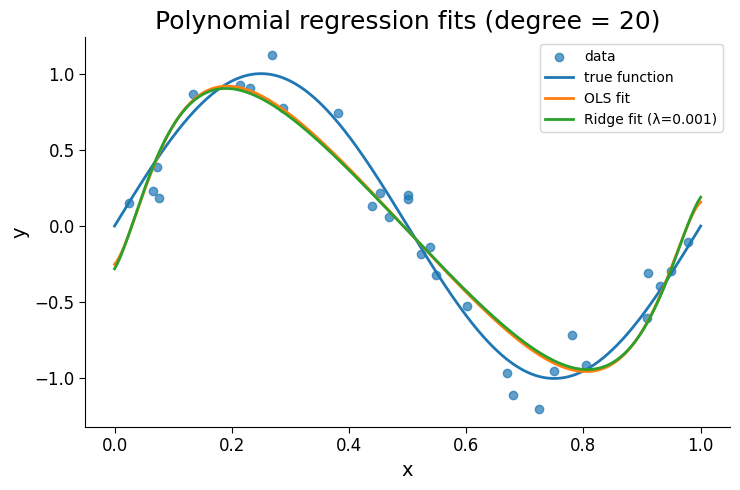

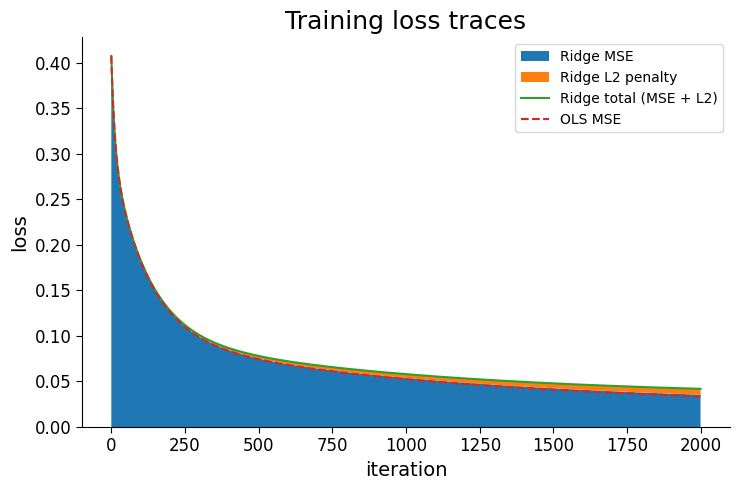

{'OLS_final_MSE': 0.03355660784233105,
 'Ridge_final_MSE': 0.03554175758799965,
 'Ridge_final_L2': 0.006403805916975055,
 'Ridge_final_total': 0.041945563504974706,
 'Check_sum(MSE+L2)': 0.041945563504974706}

In [5]:

# Polynomial regression with and without L2 regularization
# - Shows fitted curves
# - Shows training loss traces (MSE vs MSE+L2 with stacked breakdown)
#
# Notes:
# * Intercept is NOT penalized.
# * Uses plain gradient descent so the traces are meaningful.
# * Matplotlib only (no seaborn), one chart per figure, no manual colors.

from __future__ import annotations
from dataclasses import dataclass
from typing import Tuple, Dict
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("../clean_fig.mplstyle")

np.random.seed(7)


def make_data(n: int = 30, noise: float = 0.12) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Generate x in [0,1], true y = sin(2πx), add Gaussian noise."""
    x = np.sort(np.random.rand(n))
    y_true = np.sin(2 * np.pi * x)
    y = y_true + noise * np.random.randn(n)
    return x, y_true, y


def poly_features(x: np.ndarray, degree: int) -> np.ndarray:
    """Return Vandermonde-style polynomial features with intercept as column 0.
    We map x to [-1, 1] for numeric stability.
    """
    x_scaled = 2 * x - 1.0
    X = np.vstack([x_scaled ** k for k in range(degree + 1)]).T
    return X


@dataclass
class GDResult:
    w: np.ndarray
    mse_trace: np.ndarray
    l2_trace: np.ndarray
    obj_trace: np.ndarray


def train_gd(
    X: np.ndarray, y: np.ndarray, lam: float, lr: float, iters: int
) -> GDResult:
    """Train polynomial regression by gradient descent with L2 (ridge) penalty.
    Intercept (w[0]) is not penalized.
    """
    n, d = X.shape
    w = np.zeros(d)
    mse_trace, l2_trace, obj_trace = [], [], []

    # mask to avoid penalizing intercept
    reg_mask = np.ones_like(w)
    reg_mask[0] = 0.0

    for _ in range(iters):
        yhat = X @ w
        resid = yhat - y
        mse = np.mean(resid ** 2)
        l2 = lam * np.sum((reg_mask * w) ** 2)
        obj = mse + l2

        mse_trace.append(mse)
        l2_trace.append(l2)
        obj_trace.append(obj)

        # gradient: d/dw (MSE) = 2/n X^T (Xw - y), d/dw (L2) = 2λ w (except intercept)
        grad = (2.0 / n) * (X.T @ resid) + 2.0 * lam * (reg_mask * w)
        w = w - lr * grad

    return GDResult(
        w=w,
        mse_trace=np.asarray(mse_trace),
        l2_trace=np.asarray(l2_trace),
        obj_trace=np.asarray(obj_trace),
    )


# ---- Simulation parameters ----
degree = 20
n = 30
noise = 0.12
iters = 2000
lr = 0.03
lam = 1e-3  # strength of L2 penalty

# ---- Generate data and features ----
x, y_true, y = make_data(n=n, noise=noise)
X = poly_features(x, degree=degree)

# ---- Train: OLS (λ=0) and Ridge (λ>0) ----
ols = train_gd(X, y, lam=0.0, lr=lr, iters=iters)
ridge = train_gd(X, y, lam=lam, lr=lr, iters=iters)

# ---- Plot: fitted curves ----
xs = np.linspace(0, 1, 500)
Xs = poly_features(xs, degree=degree)

yhat_ols = Xs @ ols.w
yhat_ridge = Xs @ ridge.w

plt.figure(figsize=(7.5, 5))
plt.scatter(x, y, label="data", alpha=0.7)
plt.plot(xs, np.sin(2 * np.pi * xs), label="true function", linewidth=2)
plt.plot(xs, yhat_ols, label="OLS fit", linewidth=2)
plt.plot(xs, yhat_ridge, label=f"Ridge fit (λ={lam:g})", linewidth=2)
plt.title("Polynomial regression fits (degree = {})".format(degree))
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot: training loss traces ----
t = np.arange(iters)

plt.figure(figsize=(7.5, 5))
# Stacked area for Ridge: MSE and L2 components
plt.stackplot(t, ridge.mse_trace, ridge.l2_trace, labels=["Ridge MSE", "Ridge L2 penalty"])
# Overlay total objective for Ridge
plt.plot(t, ridge.obj_trace, label="Ridge total (MSE + L2)", linewidth=1.5)
# Overlay OLS MSE
plt.plot(t, ols.mse_trace, label="OLS MSE", linewidth=1.5, linestyle="--")
plt.title("Training loss traces")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# ---- Print final metrics to highlight decomposition ----
final_info = {
    "OLS_final_MSE": float(ols.mse_trace[-1]),
    "Ridge_final_MSE": float(ridge.mse_trace[-1]),
    "Ridge_final_L2": float(ridge.l2_trace[-1]),
    "Ridge_final_total": float(ridge.obj_trace[-1]),
    "Check_sum(MSE+L2)": float(ridge.mse_trace[-1] + ridge.l2_trace[-1]),
}
final_info